# 1. Data


In [1]:
import numpy as np
import importlib
from data.data_reader import Data
%load_ext autoreload
%autoreload 2

# from preprocessing import pre
Data_params_file = 'Ensemble_configs/Data_params.py'
loader = importlib.machinery.SourceFileLoader('Data_params', Data_params_file)
Data_params = loader.load_module()

In [2]:
data = Data(**Data_params.data_base)

In [3]:
x_train, x_test, y_train, y_test = data.get_train_test()

In [4]:
data.columns.levels[0]

Index(['CREB3L2', 'HYAL1', 'SHROOM4', 'SMC1A', 'SEMA3G', 'RNPS1', 'GUCY2F',
       'RAET1G', 'RPS5', 'SERINC4',
       ...
       'RAB3IP', 'GABRG3', 'WDR60', 'PSMD10', 'HYAL4', 'RPL10A', 'DCAF8L1',
       'OR2B3', 'HIGD1A', 'SERPINC1'],
      dtype='object', length=9229)

# 2. Network

In [5]:
from network.network_builder import get_tissue_specific_maps
import pandas as pd

In [6]:
# select tissues name from gtex and append it in Network_params.tissues list 
Network_params_file = 'Ensemble_configs/Network_params.py'
loader = importlib.machinery.SourceFileLoader('Network_params', Network_params_file)
Network_params = loader.load_module()

In [7]:
# TIME-CONSUMING  ALERT!!!!!!!!!!!!! 
# insted of runing this cell multiple times,
# save the tissue_maps and load for next time trainig
tissue_maps = get_tissue_specific_maps(genes=data.columns.levels[0],
                                       Network_params=Network_params)

Genes number in tissue:
Esophagus - Mucosa    8428
Testis                9004
Stomach               8436
Prostate              8474
dtype: int64
##################################################
Esophagus - Mucosa
layer # 0
pathways 1616
genes 9941
filtered_map (8428, 0)
filtered_map (8428, 0)
filtered_map (8428, 0)
layer # 1
pathways 1120
genes 1627
filtered_map (1616, 0)
filtered_map (1616, 0)
filtered_map (1616, 0)
layer # 2
pathways 505
genes 1122
filtered_map (1120, 0)
filtered_map (1120, 0)
filtered_map (1120, 0)
layer # 3
pathways 169
genes 505
filtered_map (505, 0)
filtered_map (505, 0)
filtered_map (505, 0)
layer # 4
pathways 29
genes 169
filtered_map (169, 0)
filtered_map (169, 0)
filtered_map (169, 0)
layer # 5
pathways 1
genes 29
filtered_map (29, 0)
filtered_map (29, 0)
filtered_map (29, 0)
##################################################
Testis
layer # 0
pathways 1616
genes 9941
filtered_map (9004, 0)
filtered_map (9004, 0)
filtered_map (9004, 0)
layer # 1
pathways 112

In [8]:
# for the first time save it 
# import pickle
# with open('tissue_maps.pkl', 'wb') as f:
#     pickle.dump(tissue_maps, f)

In [10]:
# for the second time load it 
import pickle
with open('tissue_maps.pkl', 'rb') as f:
    tissue_maps = pickle.load(f)

# 3. Model

## 3.1 Building

In [11]:
from model.model_builder import * 
from keras.utils import plot_model

In [12]:
Model_params_file = 'Ensemble_configs/Model_params.py'
loader = importlib.machinery.SourceFileLoader('Model_params', Model_params_file)
Model_params = loader.load_module()

In [13]:
maps = tissue_maps['Prostate']

In [14]:
model = build_pnet(data=data, maps=maps, **Model_params.model_params)

Metal device set to: Apple M1 Max
##################################################
(Genes with at least 1 conncetion to next layer)/(total conncetion to next layer)
(4520)/(17847)
(1616)/(1627)
(1120)/(1123)
(505)/(505)
(169)/(170)
(29)/(29)
##################################################
Map is:
Layer 1 conncetion: (8474, 1616)
Layer 2 conncetion: (1616, 1120)
Layer 3 conncetion: (1120, 505)
Layer 4 conncetion: (505, 169)
Layer 5 conncetion: (169, 29)
Layer 6 conncetion: (29, 1)
##################################################
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Gene(9229)-Status(3) (InputLay  [(None, 27687)]     0           []                               
 er)                                                                                              
                                                

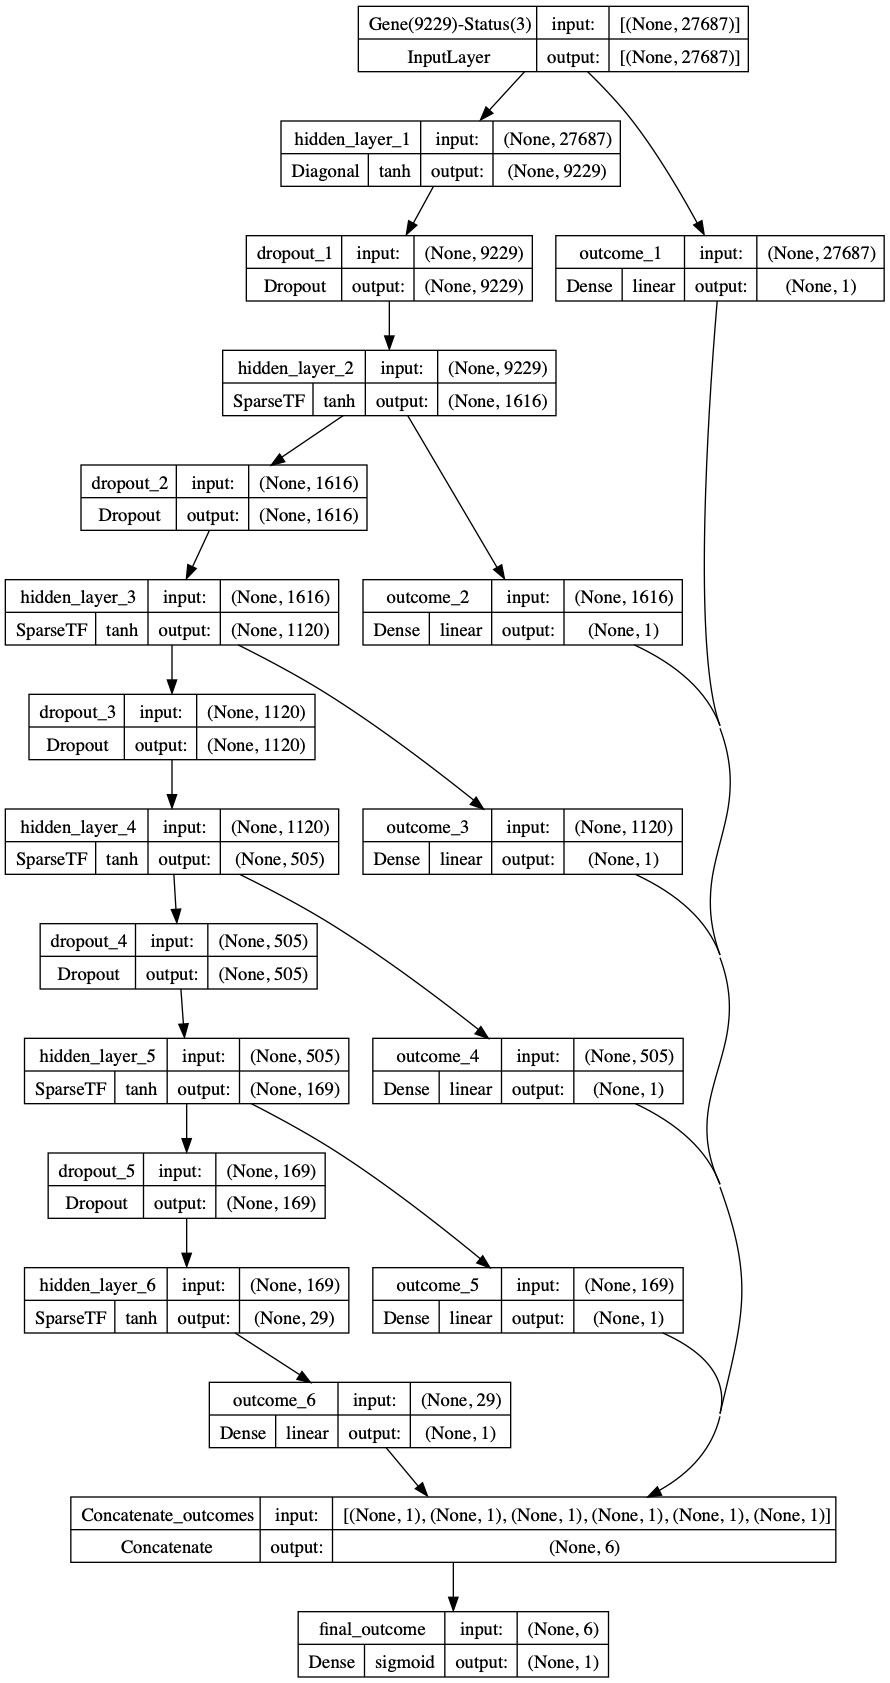

In [15]:
plot_model(model, to_file = 'pnet_model_graph.jpg',expand_nested=True,show_layer_activations=True, show_shapes = True, show_layer_names = True)

In [16]:
callbacks = get_callbacks(x_train, y_train)

In [17]:
history = model.fit(x_train,
                    y_train,
                    epochs=300,
                    batch_size=100,
                    verbose=2,
                    callbacks=callbacks)


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/300


2023-09-01 19:56:38.495885: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


8/8 - 2s - loss: 1.3759 - f1: 0.2112 - lr: 0.0010 - 2s/epoch - 197ms/step

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/300
8/8 - 0s - loss: 1.1146 - f1: 0.4830 - lr: 0.0010 - 353ms/epoch - 44ms/step

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/300
8/8 - 0s - loss: 0.9886 - f1: 0.5763 - lr: 0.0010 - 340ms/epoch - 42ms/step

Epoch 4: LearningRateScheduler setting learning rate to 0.001.
Epoch 4/300
8/8 - 0s - loss: 0.8986 - f1: 0.6801 - lr: 0.0010 - 329ms/epoch - 41ms/step

Epoch 5: LearningRateScheduler setting learning rate to 0.001.
Epoch 5/300
8/8 - 0s - loss: 0.8346 - f1: 0.6626 - lr: 0.0010 - 350ms/epoch - 44ms/step

Epoch 6: LearningRateScheduler setting learning rate to 0.001.
Epoch 6/300
8/8 - 0s - loss: 0.7821 - f1: 0.7863 - lr: 0.0010 - 351ms/epoch - 44ms/step

Epoch 7: LearningRateScheduler setting learning rate to 0.001.
Epoch 7/300
8/8 - 0s - loss: 0.7429 - f1: 0.7722 - lr: 0.0010 - 335ms/epoch - 42ms/step

Epoch 8: Lear


Epoch 55: LearningRateScheduler setting learning rate to 0.00025.
Epoch 55/300
8/8 - 0s - loss: 0.3621 - f1: 0.8622 - lr: 2.5000e-04 - 383ms/epoch - 48ms/step

Epoch 56: LearningRateScheduler setting learning rate to 0.00025.
Epoch 56/300
8/8 - 0s - loss: 0.3615 - f1: 0.9870 - lr: 2.5000e-04 - 363ms/epoch - 45ms/step

Epoch 57: LearningRateScheduler setting learning rate to 0.00025.
Epoch 57/300
8/8 - 0s - loss: 0.3610 - f1: 0.9842 - lr: 2.5000e-04 - 376ms/epoch - 47ms/step

Epoch 58: LearningRateScheduler setting learning rate to 0.00025.
Epoch 58/300
8/8 - 0s - loss: 0.3600 - f1: 0.9865 - lr: 2.5000e-04 - 368ms/epoch - 46ms/step

Epoch 59: LearningRateScheduler setting learning rate to 0.00025.
Epoch 59/300
8/8 - 0s - loss: 0.3590 - f1: 0.9853 - lr: 2.5000e-04 - 378ms/epoch - 47ms/step

Epoch 60: LearningRateScheduler setting learning rate to 0.00025.
Epoch 60/300
8/8 - 0s - loss: 0.3582 - f1: 0.9868 - lr: 2.5000e-04 - 373ms/epoch - 47ms/step

Epoch 61: LearningRateScheduler setting

Epoch 106/300
8/8 - 0s - loss: 0.3319 - f1: 0.9923 - lr: 6.2500e-05 - 402ms/epoch - 50ms/step

Epoch 107: LearningRateScheduler setting learning rate to 6.25e-05.
Epoch 107/300
8/8 - 0s - loss: 0.3317 - f1: 0.9918 - lr: 6.2500e-05 - 359ms/epoch - 45ms/step

Epoch 108: LearningRateScheduler setting learning rate to 6.25e-05.
Epoch 108/300
8/8 - 0s - loss: 0.3315 - f1: 0.9898 - lr: 6.2500e-05 - 357ms/epoch - 45ms/step

Epoch 109: LearningRateScheduler setting learning rate to 6.25e-05.
Epoch 109/300
8/8 - 0s - loss: 0.3314 - f1: 0.9901 - lr: 6.2500e-05 - 355ms/epoch - 44ms/step

Epoch 110: LearningRateScheduler setting learning rate to 6.25e-05.
Epoch 110/300
8/8 - 0s - loss: 0.3312 - f1: 0.9907 - lr: 6.2500e-05 - 379ms/epoch - 47ms/step

Epoch 111: LearningRateScheduler setting learning rate to 6.25e-05.
Epoch 111/300
8/8 - 0s - loss: 0.3311 - f1: 0.9904 - lr: 6.2500e-05 - 339ms/epoch - 42ms/step

Epoch 112: LearningRateScheduler setting learning rate to 6.25e-05.
Epoch 112/300
8/8 - 0s


Epoch 157: LearningRateScheduler setting learning rate to 1.5625e-05.
Epoch 157/300
8/8 - 0s - loss: 0.3252 - f1: 0.9925 - lr: 1.5625e-05 - 360ms/epoch - 45ms/step

Epoch 158: LearningRateScheduler setting learning rate to 1.5625e-05.
Epoch 158/300
8/8 - 0s - loss: 0.3252 - f1: 0.9921 - lr: 1.5625e-05 - 335ms/epoch - 42ms/step

Epoch 159: LearningRateScheduler setting learning rate to 1.5625e-05.
Epoch 159/300
8/8 - 0s - loss: 0.3252 - f1: 0.8677 - lr: 1.5625e-05 - 331ms/epoch - 41ms/step

Epoch 160: LearningRateScheduler setting learning rate to 1.5625e-05.
Epoch 160/300
8/8 - 0s - loss: 0.3251 - f1: 0.9908 - lr: 1.5625e-05 - 331ms/epoch - 41ms/step

Epoch 161: LearningRateScheduler setting learning rate to 1.5625e-05.
Epoch 161/300
8/8 - 0s - loss: 0.3251 - f1: 0.9902 - lr: 1.5625e-05 - 330ms/epoch - 41ms/step

Epoch 162: LearningRateScheduler setting learning rate to 1.5625e-05.
Epoch 162/300
8/8 - 0s - loss: 0.3251 - f1: 0.9901 - lr: 1.5625e-05 - 331ms/epoch - 41ms/step

Epoch 163


Epoch 207: LearningRateScheduler setting learning rate to 3.90625e-06.
Epoch 207/300
8/8 - 0s - loss: 0.3236 - f1: 0.9919 - lr: 3.9063e-06 - 337ms/epoch - 42ms/step

Epoch 208: LearningRateScheduler setting learning rate to 3.90625e-06.
Epoch 208/300
8/8 - 0s - loss: 0.3236 - f1: 0.9918 - lr: 3.9063e-06 - 352ms/epoch - 44ms/step

Epoch 209: LearningRateScheduler setting learning rate to 3.90625e-06.
Epoch 209/300
8/8 - 0s - loss: 0.3236 - f1: 0.9932 - lr: 3.9063e-06 - 352ms/epoch - 44ms/step

Epoch 210: LearningRateScheduler setting learning rate to 3.90625e-06.
Epoch 210/300
8/8 - 0s - loss: 0.3235 - f1: 0.9920 - lr: 3.9063e-06 - 327ms/epoch - 41ms/step

Epoch 211: LearningRateScheduler setting learning rate to 3.90625e-06.
Epoch 211/300
8/8 - 0s - loss: 0.3235 - f1: 0.9921 - lr: 3.9063e-06 - 328ms/epoch - 41ms/step

Epoch 212: LearningRateScheduler setting learning rate to 3.90625e-06.
Epoch 212/300
8/8 - 0s - loss: 0.3235 - f1: 0.9924 - lr: 3.9063e-06 - 341ms/epoch - 43ms/step

Epo

Epoch 256/300
8/8 - 0s - loss: 0.3231 - f1: 0.9915 - lr: 9.7656e-07 - 383ms/epoch - 48ms/step

Epoch 257: LearningRateScheduler setting learning rate to 9.765625e-07.
Epoch 257/300
8/8 - 0s - loss: 0.3231 - f1: 0.9923 - lr: 9.7656e-07 - 366ms/epoch - 46ms/step

Epoch 258: LearningRateScheduler setting learning rate to 9.765625e-07.
Epoch 258/300
8/8 - 0s - loss: 0.3231 - f1: 0.9927 - lr: 9.7656e-07 - 365ms/epoch - 46ms/step

Epoch 259: LearningRateScheduler setting learning rate to 9.765625e-07.
Epoch 259/300
8/8 - 0s - loss: 0.3231 - f1: 0.9927 - lr: 9.7656e-07 - 338ms/epoch - 42ms/step

Epoch 260: LearningRateScheduler setting learning rate to 9.765625e-07.
Epoch 260/300
8/8 - 0s - loss: 0.3231 - f1: 0.9913 - lr: 9.7656e-07 - 335ms/epoch - 42ms/step

Epoch 261: LearningRateScheduler setting learning rate to 9.765625e-07.
Epoch 261/300
8/8 - 0s - loss: 0.3231 - f1: 0.9929 - lr: 9.7656e-07 - 343ms/epoch - 43ms/step

Epoch 262: LearningRateScheduler setting learning rate to 9.765625e-07

In [18]:
y_pred = model.predict(x_test)

10/10 [==============================] - 0s 12ms/step


In [19]:
get_th(y_test, y_pred)

Best threshold to maximize the F1-score: 0.17999999999999997

Metrics for best threshold:
   accuracy  precision        f1  recall    th
8  0.796053   0.658333  0.718182    0.79  0.18


,accuracy,precision,f1,recall,th
0,0.618421,0.458763,0.605442,0.89,0.10
1,0.654605,0.485876,0.620939,0.86,0.11
2,0.703947,0.531646,0.651163,0.84,0.12
3,0.726974,0.557823,0.663968,0.82,0.13
4,0.759868,0.598540,0.691983,0.82,0.14
...,...,...,...,...,...
75,0.730263,0.800000,0.369231,0.24,0.85
76,0.726974,0.793103,0.356589,0.23,0.86
77,0.726974,0.793103,0.356589,0.23,0.87
78,0.717105,0.769231,0.317460,0.20,0.88
